In [ ]:
import sys
USING_COLAB = 'google.colab' in sys.modules

if USING_COLAB:
    !apt-get -qq update
    !apt-get -qq install -y libosmesa6-dev libgl1-mesa-glx libglfw3 libgl1-mesa-dev libglew-dev patchelf
    !apt-get install -y xvfb python-opengl ffmpeg > /dev/null 2>&1
else:
    !pip install torch torchvision torchaudio
    !pip install numpy
    !pip install tqdm
    !pip install opencv-python

!pip install matplotlib
!pip install -U mediapy
!pip install -U renderlab
!pip install -U "imageio<3.0"
!pip install stable_baselines3
!pip install numpy-stl
!pip install numba

# !git clone https://github.com/Farama-Foundation/Gymnasium-Robotics.git
# !pip install -e Gymnasium-Robotics
# sys.path.append('/content/Gymnasium-Robotics')

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Selecting previously unselected package libglx-dev:amd64.
(Reading database ... 118194 files and directories currently installed.)
Preparing to unpack .../00-libglx-dev_1.4.0-1_amd64.deb ...
Unpacking libglx-dev:amd64 (1.4.0-1) ...
Selecting previously unselected package libgl-dev:amd64.
Preparing to unpack .../01-libgl-dev_1.4.0-1_amd64.deb ...
Unpacking libgl-dev:amd64 (1.4.0-1) ...
Selecting previously unselected package libegl-dev:amd64.
Preparing to unpack .../02-libegl-dev_1.4.0-1_amd64.deb ...
Unpacking libegl-dev:amd64 (1.4.0-1) ...
Selecting previously unselected package libgles1:amd64.
Preparing to unpack .../03-libgles1_1.4.0-1_amd64.deb ...
Unpacking libgles1:amd64 (1.4.0-1) ...
Selecting previously unselected package libgles-dev:amd64.
Preparing to unpack .../04-libgles-dev_1.4.0-1_amd64

In [ ]:
from torch.utils.data import DataLoader
import gymnasium.wrappers as wrappers
import matplotlib.pyplot as plt
import torch.distributions as D
from tqdm import tqdm, trange
import torch.optim as optim
# import gymnasium_robotics
import gymnasium as gym
from gymnasium import spaces
from gymnasium.utils.env_checker import check_env
import torch.nn as nn
import numpy as np
import random
import torch

# Claude said this would speed up training
from numba import njit

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
drive_dir = '/content/drive/MyDrive/blimp_ckpts'
os.makedirs(drive_dir, exist_ok=True)

Mounted at /content/drive


Helper functions from previous homeworks

In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

cpu


In [ ]:
def visualize(env: gym.Env, algorithm=None, actor=False, video_name="test", frames=100,position=None):
    """
        Visualize a policy network for a given algorithm on a single episode
    """

    def get_action(obs):
        if not algorithm:
            return env.action_space.sample()
        else:
            if not actor:
                return algorithm(obs)
            if actor:
                return algorithm.select_action(obs)

    import cv2

    reset_kwargs = {"options": {"position": position}} if position is not None else {}

    obs, _ = env.reset(**reset_kwargs)
    env.state = position
    env.goal_position = position

    # Render one frame first to discover the actual size, then size the writer to match.
    first_frame = env.render()                 # (H, W, 3) RGB
    h, w = first_frame.shape[:2]
    video = cv2.VideoWriter(
        f"{video_name}.mp4",
        cv2.VideoWriter_fourcc(*"mp4v"),
        24,
        (w, h),                                # VideoWriter wants (width, height)
    )
    if not video.isOpened():
        raise RuntimeError("VideoWriter failed to open — check codec/ffmpeg.")

    # Write the first frame (RGB -> BGR)
    video.write(first_frame[:, :, ::-1])

    for i in range(1, frames):
        if i % 10 == 0:
            print(f"{video_name}, frame {i}")
        action = get_action(obs)
        obs, reward, terminated, truncated, _ = env.step(action)

        if terminated or truncated:
            print("terminated")
            break                              # was `continue` — that just kept stepping a dead env

        im = env.render()                      # (H, W, 3) RGB
        video.write(im[:, :, ::-1])            # BGR for OpenCV

    video.release()
    env.close()
    print(f"Video saved as {video_name}.mp4")

In [ ]:
def evaluate_policy(actor, environment, num_episodes=100, progress=True, callable=False):
    is_vec = hasattr(environment, "num_envs")
    total_rew = 0
    iterate = trange(num_episodes) if progress else range(num_episodes)
    step_rewards = []
    errors = []
    controls = []

    for _ in iterate:
        obs, info = environment.reset()
        done = False

        # Unwrap VecEnv single-env obs: (1, obs_dim) → (obs_dim,)
        raw_obs = obs[0] if is_vec and len(obs) == 1 else obs

        # If the actor is a BlimpExpert, set its target from the reset state
        if callable and hasattr(actor, 'set_target'):
            actor.set_target(
                np.array([raw_obs[0], raw_obs[1], raw_obs[2]]),
                raw_obs[5]
            )
        iter_err = []
        iter_ctrl = []
        while not done:
            # Unwrap single-env VecEnv obs for the actor
            act_obs = obs[0] if is_vec and len(obs) == 1 else obs
            action = actor(act_obs) if callable else actor.select_action(obs)

            out = environment.step(action)
            next_obs, reward, terminated, truncated, info = out
            done = terminated or truncated

            total_rew += float(np.asarray(reward).sum())
            step_rewards.append(np.asarray(reward).sum())
            if 'error' in info:
              iter_err.append(info['error'])
              iter_ctrl.append(info['control'])
            obs = next_obs
        errors.append(iter_err)
        controls.append(iter_ctrl)

    return total_rew / num_episodes, step_rewards, errors, controls

In [ ]:
seed = 695

# Setting the seed to ensure reproducability
def reseed(seed, env=None):
    torch.manual_seed(seed)
    random.seed(seed)
    np.random.seed(seed)

    if env is not None:
        env.unwrapped._np_random = gym.utils.seeding.np_random(seed)[0]

reseed(seed)

numba uses njit which is a just in time compiler - this causes the dynamics update to be incredibly fast and speed up training on CPU

In [ ]:
@njit
def physics(state,action):
    dt = 1.0 / 120.0   # 120 Hz from Paper 1, Section 4.2

    # Clip with action-specific ranges
    f = action.copy()
    #np.clip does not work with njit so just do it pythonically
    f[0] = min(max(f[0], 0.0), 1.0)
    f[1] = min(max(f[1], 0.0), 1.0)
    f[4] = min(max(f[4], 0.0), 1.0)
    f[5] = min(max(f[5], 0.0), 1.0)
    f[2] = min(max(f[2], -1.0), 1.0)
    f[3] = min(max(f[3], -1.0), 1.0)

    x, y, z, roll, pitch, yaw, u, v, w, p, q, r = state

    # Paper-identified parameters
    g_acc = 9.81

    m_RB  = 0.1249
    m_Ax  = 0.0466
    m_Ay  = 0.0466
    m_Az  = 0.0545
    m_x   = m_RB + m_Ax
    m_y   = m_RB + m_Ay
    m_z   = m_RB + m_Az

    #Symmetric so we used Icm for all inertia values
    I_x   = 0.005821
    I_y   = 0.005821
    I_z   = 0.005821

    #Drag
    D_vx  = 0.0125
    D_vy  = 0.0125
    D_vz  = 0.0480
    D_wx  = 0.000980
    D_wy  = 0.000980
    D_wz  = 0.000862

    # Geometry
    d_VM  = 0.097051
    d_VT  = 0.26
    d_MT  = d_VT - d_VM

    # Thruster params
    f_max       = 0.05
    d_yaw_arm   = 0.05
    d_roll_arm  = 0.02


    # Body-frame
    F_x_b = (f[0] + f[1] - f[4] - f[5]) * f_max
    F_y_b = 0.0
    F_z_b = -(f[2] + f[3]) * f_max

    # Body frame torque
    tau_y_b = d_MT * (f[0] + f[1] - f[4] - f[5]) * f_max

    tau_z_b = d_yaw_arm * ((f[1] + f[5]) - (f[0] + f[4])) * f_max

    tau_x_b = d_roll_arm * ((f[0] + f[4]) - (f[1] + f[5])) * f_max

    # Gravitational restoring
    tau_restore_x = -m_RB * g_acc * d_VM * np.sin(roll)
    tau_restore_y = -m_RB * g_acc * d_VM * np.sin(pitch)

    # Body-frame
    u_dot = (F_x_b - D_vx * u  +  m_y * v * r  -  m_z * w * q) / m_x
    v_dot = (F_y_b - D_vy * v  +  m_z * w * p  -  m_x * u * r) / m_y
    w_dot = (F_z_b - D_vz * w  +  m_x * u * q  -  m_y * v * p) / m_z

    p_dot = (tau_x_b + tau_restore_x - D_wx * p) / I_x
    q_dot = (tau_y_b + tau_restore_y - D_wy * q) / I_y
    r_dot = (tau_z_b                 - D_wz * r) / I_z

    # Body velocities
    u += u_dot * dt;  v += v_dot * dt;  w += w_dot * dt
    p += p_dot * dt;  q += q_dot * dt;  r += r_dot * dt

    # Inertial kinematics
    cr, sr = np.cos(roll),  np.sin(roll)
    cp, sp = np.cos(pitch), np.sin(pitch)
    cy, sy = np.cos(yaw),   np.sin(yaw)
    tp     = np.tan(pitch)

    x_dot = (cy*cp)*u + (cy*sp*sr - sy*cr)*v + (cy*sp*cr + sy*sr)*w
    y_dot = (sy*cp)*u + (sy*sp*sr + cy*cr)*v + (sy*sp*cr - cy*sr)*w
    z_dot = (-sp)   *u + (cp*sr)            *v + (cp*cr)         *w

    roll_dot  = p + sr * tp * q + cr * tp * r
    pitch_dot =     cr      * q - sr      * r
    yaw_dot   = (sr / cp)   * q + (cr / cp) * r

    # Integrate
    x     += x_dot     * dt
    y     += y_dot     * dt
    z     += z_dot     * dt
    roll  += roll_dot  * dt
    pitch += pitch_dot * dt
    yaw    = (yaw + yaw_dot * dt) % (2.0 * np.pi)

    return np.array(
        [x, y, z, roll, pitch, yaw, u, v, w, p, q, r],
        dtype=np.float32,
    )

Creating the gymnasium environment based on the blimp dynamics papers

[INSERT LINKS]

Used GenAI to generate the step function as the EOM are incredibly involved and this saved me a week of coding lol

In [ ]:
# Setup the custom gymnasium environment that uses the blimp dynamics
class RealBlimpEnv(gym.Env):
  def __init__(self, mesh_path=None, render_mode=None):
        super().__init__()
        self.metadata = { 'render_modes': ['human', 'rgb_array'], 'render_fps': 30 }
        # x, y, z, roll, pitch, yaw, u, v, w, p, q, r
        self.observation_space = spaces.Box(
            low  = np.array([-10.0, -10.0, -10.0, -0.5, -0.5, 0.0,
                             -2.0,  -2.0,  -2.0, -1.0, -1.0, -1.0], dtype=np.float32),
            high = np.array([ 10.0,  10.0,  10.0,  0.5,  0.5, 2*np.pi,
                              2.0,   2.0,   2.0,  1.0,  1.0,  1.0], dtype=np.float32),
        )

        self.action_space = spaces.Box(
            low  = np.array([0.0, 0.0, -1.0, -1.0, 0.0, 0.0], dtype=np.float32),
            high = np.array([1.0, 1.0,  1.0,  1.0, 1.0, 1.0], dtype=np.float32),
        )


        self.state  = None
        self._step  = 0


        self.render_mode = render_mode
        self._mesh_vertices = None        # (N, 3, 3) — N triangles, 3 verts, xyz
        if mesh_path is not None:
            from stl import mesh as stl_mesh
            m = stl_mesh.Mesh.from_file(mesh_path)
            self._mesh_vertices = m.vectors.astype(np.float32)  # shape (N, 3, 3)

        self._fig = None
        self._ax = None
        self._trail = []

        self.info = {}

  def reset(self,seed=None,options=None):
    super().reset(seed=seed)

    # Tighter spawn than observation_space: roll/pitch under termination
    # threshold (0.45), and modest initial velocities/rates.
    low  = np.array([-8.0, -8.0, -8.0, -0.3, -0.3, 0.0,
                     -0.5,  -0.5,  -0.5, -0.3, -0.3, -0.3], dtype=np.float32)
    high = np.array([ 8.0,  8.0,  8.0,  0.5,  0.5, 2*np.pi,
                      0.5,   0.5,   0.5,  0.5,  0.5,  0.5], dtype=np.float32)
    if options is not None and "position" in options:
        x = np.asarray(options["position"], dtype=np.float32)
    else:
        x = self.np_random.uniform(low=low, high=high).astype(np.float32)
    self.state = x
    self.goal_position = np.array([self.state[0], self.state[1], self.state[2], 0.0, 0.0, self.state[5]])
    self.prev_dist = np.linalg.norm(self.state[0:6] - self.goal_position)
    self._step = 0

    self.info = {}

    return x.copy(),self.info


  def step(self, action):
      self.state = physics(self.state, action)
      self._step += 1

      pitch, roll = self.state[3:5]

      obs        = self.state.copy()
      yaw_err = ((self.state[5] - self.goal_position[5] + np.pi) % (2*np.pi)) - np.pi
      err = np.array([
          self.state[0]-self.goal_position[0],
          self.state[1]-self.goal_position[1],
          self.state[2]-self.goal_position[2],
          self.state[3]-self.goal_position[3],
          self.state[4]-self.goal_position[4],
          yaw_err,
      ])
      self.info['error'] = err
      self.info['control'] =action

      current_dist = np.linalg.norm(err)

      reward = (self.prev_dist - current_dist) # Reward for improving the distance, closer = + reward

      self.prev_dist = current_dist

      at_correct_location = np.linalg.norm(err[0:3]) < 0.2 # Reward if the spatial x,y,z error is small
      at_correct_angle = np.linalg.norm(err[3:5]) < 0.2 # Reward if the roll and pitch angles are small

      reward = reward+0.001 if at_correct_location else reward
      reward = reward+0.001 if at_correct_angle else reward

      terminated = abs(pitch)>0.5 or abs(roll)>0.5
      truncated  = self._step >= 1000

      return obs, reward, terminated, truncated, self.info

  def render(self, mode="rgb_array"):
      import matplotlib
      matplotlib.use("Agg")
      import matplotlib.pyplot as plt
      from mpl_toolkits.mplot3d.art3d import Poly3DCollection

      if self._fig is None:
          self._fig = plt.figure(figsize=(6, 4), dpi=100)
          self._ax  = self._fig.add_subplot(111, projection="3d")

      x, y, z, roll, pitch, yaw, *_ = self.state
      self._trail.append((x, y, z))
      if len(self._trail) > 200:
          self._trail.pop(0)

      # Body→inertial rotation (ZYX Euler, NED)
      cr, sr = np.cos(roll),  np.sin(roll)
      cp, sp = np.cos(pitch), np.sin(pitch)
      cy, sy = np.cos(yaw),   np.sin(yaw)
      R = np.array([
          [cy*cp, cy*sp*sr - sy*cr, cy*sp*cr + sy*sr],
          [sy*cp, sy*sp*sr + cy*cr, sy*sp*cr - cy*sr],
          [-sp,   cp*sr,             cp*cr           ],
      ])

      ax = self._ax
      ax.cla()
      ax.set_xlim(-10, 10); ax.set_ylim(-10, 10); ax.set_zlim(10, -10)
      ax.set_xlabel("X"); ax.set_ylabel("Y"); ax.set_zlabel("Z (NED)")

      if self._mesh_vertices is not None:
          # Apply rotation to every vertex of every triangle, then translate.
          # mesh_vertices: (N, 3, 3) → (N*3, 3) → rotate → reshape back.
          verts = self._mesh_vertices.reshape(-1, 3) @ R.T + np.array([x, y, z])
          verts = verts.reshape(-1, 3, 3)
          poly = Poly3DCollection(verts, alpha=0.7, facecolor="0.6",
                                  edgecolor="k", linewidth=0.1)
          ax.add_collection3d(poly)
      else:
          ax.scatter([x], [y], [z], s=80, c="k")

      if len(self._trail) > 1:
          tr = np.array(self._trail)
          ax.plot(tr[:, 0], tr[:, 1], tr[:, 2], lw=1, alpha=0.4)

      self._fig.canvas.draw()
      buf = np.asarray(self._fig.canvas.buffer_rgba())[:, :, :3]
      return buf

gym.register(id="RealBlimpEnv",entry_point=RealBlimpEnv) # Register the environment via gym



/usr/local/lib/python3.12/dist-packages/gymnasium/envs/registration.py:636: UserWarning: WARN: Overriding environment RealBlimpEnv already in registry.
  logger.warn(f"Overriding environment {new_spec.id} already in registry.")


BlimpExpert is a PID controller also outlined in

[INSERT PAPER]

This is used to collect more consistent data than a random policy and the PPO should be able to improve from the information learned on the data received from this expert

In [ ]:
class BlimpExpert(object):
    """
    PD station-keeping controller.
    Drives the blimp to target_pos with roll=0, pitch=0, yaw=0.

    Motor layout (NED convention, Z_B points down):
      0,1: front pair, thrust +X_B,  action ∈ [0, 1]
      4,5: back  pair, thrust -X_B,  action ∈ [0, 1]
      2,3: vertical, bidirectional,  action ∈ [-1, 1]  (>0 → upward force)

    Sign conventions confirmed from env step():
      - positive tau_y_b  →  nose pitches DOWN  (front motors below CM)
      - positive tau_x_b  →  roll increases     (port > starboard)
      - positive tau_z_b  →  yaw increases      (starboard > port)
    """
    def __init__(self, target_pos=np.zeros(3), target_yaw=0.0):
        self.target_pos = np.asarray(target_pos, dtype=np.float32)
        self.target_yaw = float(target_yaw)

        # Position P gains
        self.kp_x   = 0.8   # surge
        self.kp_z   = 1.1   # heave
        self.kp_yaw = 0.4   # yaw angle

        # Velocity / rate D gains
        self.kd_x   = 0.4   # surge rate (u)
        self.kd_z   = 0.6   # heave rate (w)
        self.kd_yaw = 0.2   # yaw rate   (r)

        # Attitude angle P gains (actively drive roll/pitch to 0)
        self.kp_roll  = 1.0
        self.kp_pitch = 0.5

        # Attitude rate D gains
        self.kd_p = 0.8   # roll  rate (p)
        self.kd_q = 0.2   # pitch rate (q)

    def set_target(self, target_pos, target_yaw):
        self.target_pos = np.asarray(target_pos, dtype=np.float32)
        self.target_yaw = float(target_yaw)

    def __call__(self, obs):
        x, y, z, roll, pitch, yaw, u, v, w, p, q, r = obs

        # Position error
        ex_n = self.target_pos[0] - x
        ey_n = self.target_pos[1] - y
        ez_n = self.target_pos[2] - z
        cy_, sy_ = np.cos(yaw), np.sin(yaw)
        e_surge =  cy_ * ex_n + sy_ * ey_n

        e_yaw = (self.target_yaw - yaw + np.pi) % (2 * np.pi) - np.pi # Wrap this error to avoid 0 to 2pi jump

        # PD update
        cmd_surge = self.kp_x   * e_surge - self.kd_x   * u
        cmd_heave = self.kp_z   * ez_n    - self.kd_z   * w
        cmd_yaw   = self.kp_yaw * e_yaw   - self.kd_yaw * r


        cmd_roll = -self.kp_roll * roll - self.kd_p * p
        cmd_pitch = -self.kp_pitch * pitch + self.kd_q * q

        # Motor mixer
        bias = 0.5
        f0 = bias + 0.5 * ( cmd_surge - cmd_pitch - cmd_yaw + cmd_roll)  # front-port
        f1 = bias + 0.5 * ( cmd_surge - cmd_pitch + cmd_yaw - cmd_roll)  # front-stbd
        f4 = bias + 0.5 * (-cmd_surge + cmd_pitch - cmd_yaw + cmd_roll)  # back-port
        f5 = bias + 0.5 * (-cmd_surge + cmd_pitch + cmd_yaw - cmd_roll)  # back-stbd

        # Heave: action > 0 → upward force, so negate cmd_heave (NED z-down)
        f2 = -0.5 * cmd_heave
        f3 = -0.5 * cmd_heave

        action = np.array([f0, f1, f2, f3, f4, f5], dtype=np.float32)
        action[[0, 1, 4, 5]] = np.clip(action[[0, 1, 4, 5]], 0.0, 1.0)
        action[[2, 3]]       = np.clip(action[[2, 3]],      -1.0, 1.0)
        return action

expert = BlimpExpert(target_pos=np.array([0.0, 0.0, 0.0]), target_yaw=0.0)

Vectorized environment wrapper to initialize the blimp gym environment

In [ ]:
# Let's initialize the environment first
reseed(seed)

def make_blimp_env(max_steps=10000,seed=None):
    env_kwargs = {"mesh_path": "mesh.stl", "render_mode": "rgb_array"}
    env = gym.make("RealBlimpEnv",**env_kwargs)
    env = wrappers.TimeLimit(env, max_episode_steps=max_steps)
    env = wrappers.RecordEpisodeStatistics(env)
    if seed is not None:
      env.reset(seed=seed)
    return env

def make_training_env(max_steps=10000): # just doesnt try to render every timestep
    env_kwargs = {"mesh_path": "mesh.stl", "render_mode": None}
    env = gym.make("RealBlimpEnv",**env_kwargs)
    env = wrappers.TimeLimit(env, max_episode_steps=max_steps)
    env = wrappers.RecordEpisodeStatistics(env)
    if seed is not None:
      env.reset(seed=seed)
    return env

real_env = make_blimp_env()

/usr/local/lib/python3.12/dist-packages/gymnasium/envs/registration.py:728: UserWarning: WARN: The environment is being initialised with render_mode='rgb_array' that is not in the possible render_modes ([]).
  logger.warn(


Evaluate expert policy on the real environment as a baseline
- goal is to beat this value through PPO learning

In [ ]:
reward, rewards, errors, controls = evaluate_policy(expert,real_env,callable=True)
print(f'Expert reward: {reward}')

100%|██████████| 100/100 [00:05<00:00, 19.92it/s]


Expert reward: -0.24263962090239313


In [ ]:
# Setting up stable baseline
from stable_baselines3 import PPO
from stable_baselines3.common.callbacks import BaseCallback
from stable_baselines3.common.vec_env.base_vec_env import VecEnv
from stable_baselines3.common.env_util import make_vec_env

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


This wrapped changes the observation output from the raw state to an error between the state and the goal position which is much more intuitive to try to minimize

In [ ]:
class ErrorObsWrapper(gym.ObservationWrapper):
    """Converts RealBlimpEnv absolute obs to error-based obs
       matching DynamicsBlimpEnv._get_obs() format."""

    def __init__(self, env):
        super().__init__(env)
        # obs space stays same shape (12,), just reinterpreted

    def reset(self, **kwargs):
        obs, info = self.env.reset(**kwargs)
        # goal is set inside RealBlimpEnv.reset() already
        self.goal_position = self.env.unwrapped.goal_position.copy()
        return self._to_error(obs), info

    def observation(self, obs):
        return self._to_error(obs)

    def _to_error(self, obs):
        yaw_err = ((obs[5] - self.goal_position[5] + np.pi) % (2 * np.pi)) - np.pi
        return np.array([
            obs[0] - self.goal_position[0],
            obs[1] - self.goal_position[1],
            obs[2] - self.goal_position[2],
            obs[3],
            obs[4],
            yaw_err,
            obs[6], obs[7], obs[8],
            obs[9], obs[10], obs[11],
        ], dtype=np.float32)
real_env_wrapped = ErrorObsWrapper(real_env)

In [ ]:
class BlimpActor():
    def __init__(self, ckpt: str=None, environment: VecEnv=None, model=None):
        '''
          Requires environment to be a 1-vectorized environment

          The `ckpt` is a .zip file path that leads to the checkpoint you want
          to use for this particular actor.

          If the `model` variable is provided, then this constructor will store
          that as the internal representing model instead of loading one from the
          checkpoint path
        '''
        assert ckpt is not None or model is not None

        if model is not None:
            self.model = model
            return

        # TODO: Load checkpoint
        self.model = PPO.load(ckpt)
        # END TODO

    def select_action(self, obs):
        '''Gives the action prediction of this particular actor'''

        # TODO: Select action
        action, next_hidden = self.model.predict(obs)
        return action
        # END TODO

In [ ]:
class PPOCallback(BaseCallback):
    def __init__(self, verbose=0, save_path='default', save_freq = 1024, save_thresh = 500_000, eval_env=None, real_eval_env = None):
        super(PPOCallback, self).__init__(verbose)
        self.rewards = []

        self.save_freq = save_freq
        self.save_thresh = save_thresh
        self.min_reward = -np.inf
        self.actor = None
        self.eval_env = eval_env

        self.save_path = save_path
        self.eval_steps = []
        self.eval_rewards = []

        self.real_eval_env = real_eval_env
        self.best_real_reward = -np.inf

    def _init_callback(self) -> None:
        pass

    def _on_training_start(self) -> None:
        """
        This method is called before the first rollout starts.
        """
        self.actor = BlimpActor(model=self.model)

    def _on_rollout_start(self) -> None:
        """
        A rollout is the collection of environment interaction
        using the current policy.
        This event is triggered before collecting new samples.
        """
        pass

    def _on_rollout_end(self) -> None:
        """
        This event is triggered before updating the policy.
        """
        episode_info = self.model.ep_info_buffer
        rewards = [ep_info['r'] for ep_info in episode_info]
        mean_rewards = np.mean(rewards)
        self.rewards.append(mean_rewards)

    def _on_step(self) -> bool:
        """
        This method will be called by the model after each call to `env.step()`.

        For child callback (of an `EventCallback`), this will be called
        when the event is triggered.

        :return: If the callback returns False, training is aborted early.
        """
        if self.eval_env is None:
            return True

        if self.num_timesteps > self.save_thresh and self.num_timesteps % self.save_freq == 0 and self.num_timesteps != 0:
            mean_reward = evaluate_policy(self.actor, environment=self.eval_env, num_episodes=20)
            print(f'evaluating {self.num_timesteps=}, {mean_reward=}=======')

            self.eval_steps.append(self.num_timesteps)
            self.eval_rewards.append(mean_reward)
            if mean_reward > self.min_reward:
                self.min_reward = mean_reward
                self.model.save(self.save_path)
                print(f'model saved on eval reward: {self.min_reward}')

        return True

    def _on_training_end(self) -> None:
        """
        This event is triggered before exiting the `learn()` method.
        """
        print(f'model saved on eval reward: {self.min_reward}')

        plt.plot(self.eval_steps, self.eval_rewards, c='red')
        plt.xlabel('Episodes')
        plt.ylabel('Rewards')
        plt.title('Rewards over Episodes')

        plt.show()
        plt.close()

Train the dynamics model using MlpPolicy
Iterations:
- Small model, absolute state
- Reward simply -curr_dist
- Larger model, GELU instead of tanh
- Change from predicting next state to change in state
- Denser reward shaping
- Update step to be based on the error rather than the absolute state in dynamics environment
- Removed the dynamics learning - way too complex and would require a deeper network and larger dataset which is not super realistic for the scope of this final project.

Train a PPO learner on the real environment using the 6DOF blimp dynamics

In [ ]:
import os
cpus = os.cpu_count()
n_env = 4*cpus
print(n_env)

32


In [ ]:
hyperparameters = {
    "n_steps": 2048,
    "ent_coef": 0.01, # Add an exploration bonus to avoid early convergence
    "policy_kwargs": {
        "net_arch": {
            "pi": [512, 512],
            "vf": [512, 512],
        },
        "activation_fn": nn.GELU,
    },
}

In [ ]:
real_vec_env = make_vec_env(lambda: ErrorObsWrapper(make_training_env(max_steps=400)), n_env, seed)

train_PPO = False
ckpt = 'best_reward'
if train_PPO:
  train_steps = 10_000_000
  save_steps = train_steps//50
  save_thresh = train_steps/2 # Get 25% through training before starting to evaluate model

  model_free_callback = PPOCallback(save_path=ckpt, eval_env=real_vec_env,save_freq=save_steps,save_thresh=save_thresh)
  model_free_learner = PPO(
        policy='MlpPolicy',
        env=real_vec_env,
        n_steps=hyperparameters['n_steps'],
        ent_coef=hyperparameters['ent_coef'], #add a small exploration bonus
        batch_size=1024,
        gamma=0.99,
        # gae_lambda=0.98,
        device='cpu',
        policy_kwargs=hyperparameters['policy_kwargs'],
    )
  model_free_learner.learn(train_steps, callback=model_free_callback)
  model_free_learner.save(os.path.join(drive_dir, ckpt))
else:
  model_free_learner = PPO.load(f'{ckpt}.zip',env=real_vec_env)

In [ ]:
#Load and continue training
continue_training=False
if continue_training:
  fp = '10m_400step_largest_net_reshaped_reward.zip'
  ckpt = '12m_400step_largest_net_reshaped_reward'
  model_free_learner = PPO.load(fp, env=real_vec_env)

  train_steps = 2_000_000
  save_steps = train_steps//50
  save_thresh = train_steps/4 # Get 25% through training before starting to evaluate model

  model_free_callback = PPOCallback(save_path=ckpt, eval_env=real_vec_env,save_freq=save_steps,save_thresh=save_thresh)
  model_free_learner.learn(train_steps,callback=model_free_callback)
  model_free_learner.save(os.path.join(drive_dir, ckpt))

Model-Free:
- Expert PID is too good which led to a sparse dataset
- PPO could not learn from dynamics model due to unseen data in dataset
  - Likely could be solved with larger dataset+DAgger+more training but would be too large of a scope
  - This approach moreso mirrors real world data collection -> dynamics learning -> controller but I needed to introduce entropy, noise, real-world consequences to deal with the odd initial positions
- Shifted to model-based to be more scoped for this assignment with the goal of beating PID controller by using RL on the same environment with the same reward shaping
  - PPO uses error as the observation, similar to PID


This system is underactuated so having perfect control is not feasible. However, a learner should be able to improve over a PD controller as feedback compensation is linear and physically unable to fully compensate an underactuated system. (check this)


Model-Based:

2.5 million timesteps, reward = last_dist - curr_dist -> slightly better than exper

5 million, very shaped reward, worse than random (must have been bad shaping)

5 million, reward = (last-curr) + bonus around equilibrium CURRENT BEST

10 million, 0.98 gae, 0.997 lambda, worse than 5 million 200 step

Increasing model architecture to 256 neuron layer, 200 steps, lambda 0.99 CURRENT BEST (5 mill is unnecessary)

512 layer best, stals around 11 million, 400 step looks ideal FINAL MODEL

In [ ]:
scores = []
all_episodes_rewards = []
test_PPO = False
for _ in range(10):
  n_ep = 50
  if train_PPO or test_PPO:
    learner_actor = BlimpActor(ckpt=f'{ckpt}.zip', environment=real_vec_env)
  else:
    learner_actor = BlimpActor(model=model_free_learner, environment=real_vec_env)
  expert_score, expert_rewards  = evaluate_policy(expert,        real_env,         num_episodes=n_ep, callable=True)
  random_score, random_rewards  = evaluate_policy(lambda o: real_env.action_space.sample(), real_env, num_episodes=n_ep, callable=True)
  learner_score, learner_rewards = evaluate_policy(learner_actor, real_env_wrapped, num_episodes=n_ep)
  print(f'Expert: {expert_score}, Random: {random_score}, Learner: {learner_score}')
  scores.append((expert_score, random_score, learner_score))
  all_episodes_rewards.append((expert_rewards, random_rewards, learner_rewards))

scores = np.array(scores)
print(f'Average rewards, expert: {np.mean(scores[:,0])}, learner: {np.mean(scores[:,2])}, random: {np.mean(scores[:,1])}')

plt.plot(np.arange(scores.shape[0]), scores[:,0])
plt.plot(np.arange(scores.shape[0]), scores[:,1])
plt.plot(np.arange(scores.shape[0]), scores[:,2])
plt.legend(["Expert","Random","Learner"])
plt.grid()
plt.title("Reward Across Different Seeds")
plt.xlabel("Iter")
plt.ylabel("Reward")
plt.show()

100%|██████████| 50/50 [00:34<00:00,  1.45it/s]


Expert: -0.36098672248870706, Random: -1.842083428483035, Learner: 0.318647966095449


100%|██████████| 50/50 [00:36<00:00,  1.39it/s]


Expert: -0.26089914387304536, Random: -1.6879053260119123, Learner: 0.2552257438851845


100%|██████████| 50/50 [00:39<00:00,  1.28it/s]


...

Expert: -0.14233765233082146, Random: -1.7773881504328708, Learner: 0.30388169529307685


100%|██████████| 50/50 [00:36<00:00,  1.36it/s]


Expert: -0.216875233847575, Random: -1.674804547446316, Learner: 0.21552020837034636


100%|██████████| 50/50 [00:36<00:00,  1.38it/s]


Expert: -0.3943735802318469, Random: -1.9665849055059408, Learner: 0.3547850926208406
Average rewards, expert: -0.18486527561084423, learner: 0.30940011829771735, random: -1.8048879491279313


In [ ]:

scores = np.asarray(scores)             # (n_iters, n_seeds)
n_iters, n_seeds = scores.shape
colors = plt.cm.tab10(range(n_seeds))

fig, (ax_ep, ax_mean) = plt.subplots(
    2, 1, figsize=(10, 6), sharex=True,
    gridspec_kw={"height_ratios": [1, 1]},   # bump first to e.g. [2, 1] if you want the cloud bigger
)

labels=["Expert","Random","Learner"]
for s in range(n_seeds):
    ep_x, ep_y = [], []
    for it in range(n_iters):
        rewards = all_episodes_rewards[it][s]
        n_eps = len(rewards)
        ep_x.extend(it + np.arange(n_eps) / n_eps)
        ep_y.extend(rewards)
    ax_ep.plot(ep_x, ep_y, color=colors[s], alpha=0.4, linewidth=1)
    ax_mean.plot(np.arange(n_iters), scores[:, s],
                 color=colors[s], linewidth=2, label=labels[s])

ax_ep.set_ylabel("Episode reward")
ax_mean.set_ylabel("Mean reward")
ax_mean.set_xlabel("Iteration")
ax_mean.legend()
for a in (ax_ep, ax_mean):
    a.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
plt.savefig(f'comparison.png')

In [ ]:
low  = np.array([-7.0, -7.0, -7.0, -0.3, -0.3, 0.0,
                  -0.1,  -0.1,  -0.1, -0.1, -0.1, -0.1], dtype=np.float32)
high = np.array([ 7.0,  7.0,  7.0,  0.3,  0.3, 2*np.pi,
                  0.1,   0.1,   0.1,  0.1,  0.1,  0.1], dtype=np.float32)
viz_env = make_blimp_env(seed=2983719)
position = viz_env.np_random.uniform(low=low, high=high).astype(np.float32)

visualize(viz_env, expert,video_name="expert",frames=300,position=position)
visualize(ErrorObsWrapper(viz_env), learner_actor, actor=True,video_name="actor",frames=300,position=position)

/usr/local/lib/python3.12/dist-packages/gymnasium/envs/registration.py:728: UserWarning: WARN: The environment is being initialised with render_mode='rgb_array' that is not in the possible render_modes ([]).
  logger.warn(


expert, frame 10
expert, frame 20
expert, frame 30
expert, frame 40
expert, frame 50
expert, frame 60
expert, frame 70
expert, frame 80
expert, frame 90
expert, frame 100
expert, frame 110
expert, frame 120
expert, frame 130
expert, frame 140
expert, frame 150
expert, frame 160
expert, frame 170
expert, frame 180
expert, frame 190
expert, frame 200
expert, frame 210
expert, frame 220
expert, frame 230
expert, frame 240
expert, frame 250
expert, frame 260
expert, frame 270
expert, frame 280
expert, frame 290
Video saved as expert.mp4
actor, frame 10
actor, frame 20
actor, frame 30
actor, frame 40
actor, frame 50
actor, frame 60
actor, frame 70
actor, frame 80
actor, frame 90
actor, frame 100
actor, frame 110
actor, frame 120
actor, frame 130
actor, frame 140
actor, frame 150
actor, frame 160
actor, frame 170
actor, frame 180
actor, frame 190
actor, frame 200
actor, frame 210
actor, frame 220
actor, frame 230
actor, frame 240
actor, frame 250
actor, frame 260
actor, frame 270
actor, fram

Getting error metrics, control metrics

100 episodes, plot error over time

In [ ]:
n_ep = 50
learner_actor = BlimpActor(ckpt=f'{ckpt}.zip', environment=real_vec_env)
expert_rw, e_rwds, e_err, e_ctrl = evaluate_policy(expert,real_env,callable=True,num_episodes=n_ep)
learner_rw, learner_rwds, learner_err, learner_ctrl = evaluate_policy(learner_actor,real_env_wrapped,num_episodes=n_ep)

100%|██████████| 50/50 [00:23<00:00,  2.17it/s]


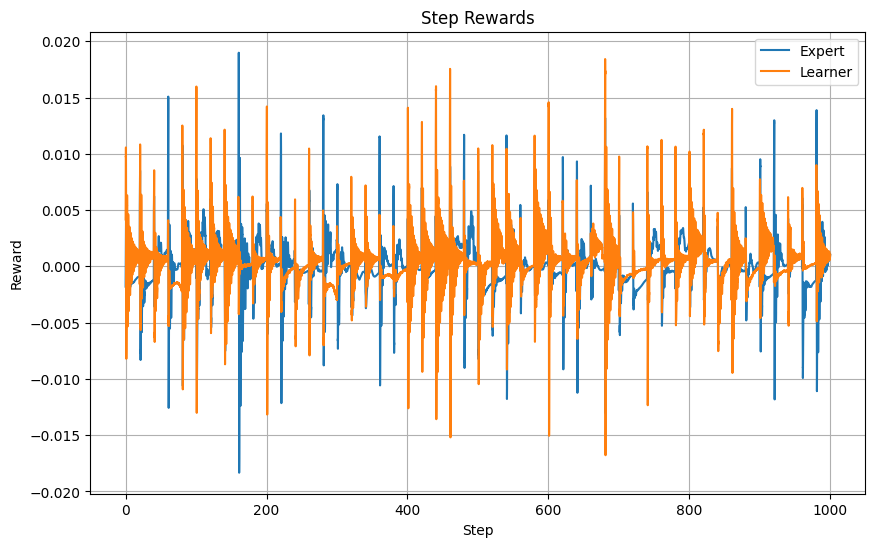

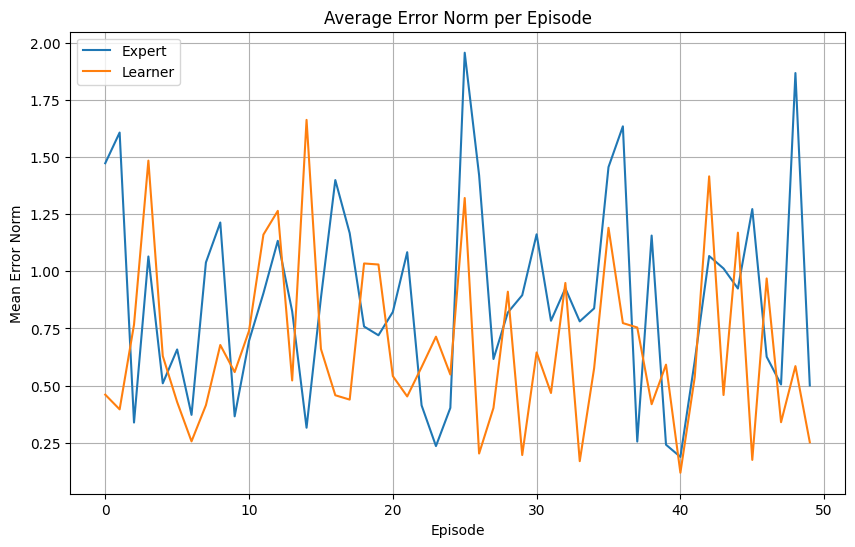

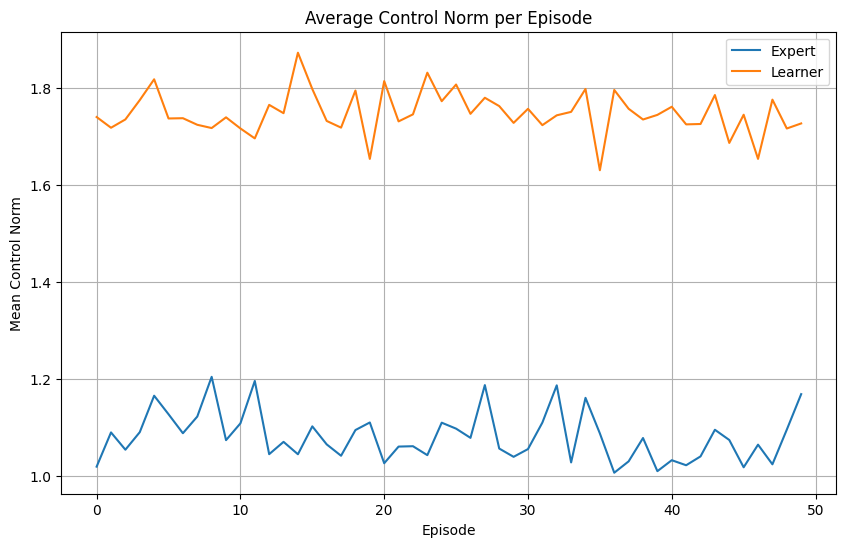

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(np.arange(0,len(e_rwds))/n_ep,e_rwds)
plt.plot(np.arange(0,len(learner_rwds))/n_ep,learner_rwds)
plt.legend(["Expert","Learner"])
plt.grid()
plt.title("Step Rewards")
plt.xlabel("Step")
plt.ylabel("Reward")
plt.savefig("step_rewards_plot.png")
plt.show()

expert_mean_err = []
learner_mean_err = []

expert_mean_ctrl = []
learner_mean_ctrl = []

for i in range(n_ep):
    # Calculate the mean of the error norms for each episode
    e_norm = np.mean([np.linalg.norm(err) for err in e_err[i]])
    l_norm = np.mean([np.linalg.norm(err) for err in learner_err[i]])
    e_norm_ctrl = np.mean([np.linalg.norm(ctrl) for ctrl in e_ctrl[i]])
    l_norm_ctrl = np.mean([np.linalg.norm(ctrl) for ctrl in learner_ctrl[i]])
    expert_mean_ctrl.append(e_norm_ctrl)
    learner_mean_ctrl.append(l_norm_ctrl)
    expert_mean_err.append(e_norm)
    learner_mean_err.append(l_norm)

plt.figure(figsize=(10, 6))
plt.plot(np.arange(n_ep), expert_mean_err, label='Expert')
plt.plot(np.arange(n_ep), learner_mean_err, label='Learner')
plt.title("Average Error Norm per Episode")
plt.xlabel("Episode")
plt.ylabel("Mean Error Norm")
plt.legend()
plt.grid(True)
plt.savefig("average_error.png")
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(np.arange(n_ep), expert_mean_ctrl, label='Expert')
plt.plot(np.arange(n_ep), learner_mean_ctrl, label='Learner')
plt.title("Average Control Norm per Episode")
plt.xlabel("Episode")
plt.ylabel("Mean Control Norm")
plt.legend()
plt.grid(True)
plt.savefig("average_control.png")
plt.show()